# Principles of Data Analytics Problems

In [1]:
# Importing the packages required for analysis:
# Data frames.
import pandas as pd
# Numerical arrays.
import numpy as np
# Statistical data evaluation.
import matplotlib.pyplot as plt
# Regression validation. 
from scipy.stats import linregress

Pandas is used for loading and analysing structured datasets.
NumPy provides numerical tools for mathematical calculations.
Matplotlib is used to create visualisations to explore patterns in data.
https://www.kaggle.com/code/chats351/introduction-to-numpy-pandas-and-matplotlib

## Problem 5: The Penguins Dataset

In [2]:
# Read directly from url in Pandas - using a source from a GitHub repository. We are using the Palmer Penguins dataset, which contains measurements from 3 different species collected in Antarctica and is often used as an alternative to the Iris dataset. https://allisonhorst.github.io/palmerpenguins/articles/intro.html
url = "https://raw.githubusercontent.com/ianmcloughlin/principles-of-data-analytics/main/data/penguins.csv"

df = pd.read_csv(url)
# Using head to view the first few rows to view the structure and values of the data.
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# Using the describe method in Pandas to provide summary measures: mean, standard deviationm min and max.
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


The descriptive statistics provide an overview of the physical characteristics of the penguins in the dataset. There are counts of 342 for all stats apart from year, which suggests that we have two 'incomplete' entries in the dataset. The mean provides the average value for each measurement, giving an indication of the typical penguin in the dataset.

The standard deviation shows how much variation exists in each measurement, with larger values indicating greater diversity among penguins. The standard deviation shows that body mass (802 g) and flipper length (14.1 mm) vary more than bill depth (2.0 mm), indicating greater diversity in overall body size than in bill thickness.
This suggests noticeable differences in penguin size, likely influenced by the presence of multiple species.

The quartiles (25%, 50%, and 75%) divide the data into four equal parts, helping to show how measurements are distributed and whether the data is skewed or evenly spread across the population. This furher highlights the variation in penguin size, body mass ranges from 2,700 g to 6,300 g, and flipper length ranges from 172 mm to 231 mm, showing a wide spread of values.

Overall, the summary statistics suggest that while penguins share common physical characteristics, there is substantial variation in size and shape within the dataset, consistent with a population composed of different penguin species.

## Problem 6: Visualising Distributions

Taking body mass as my variable to create plots for analysis using matplotlab.

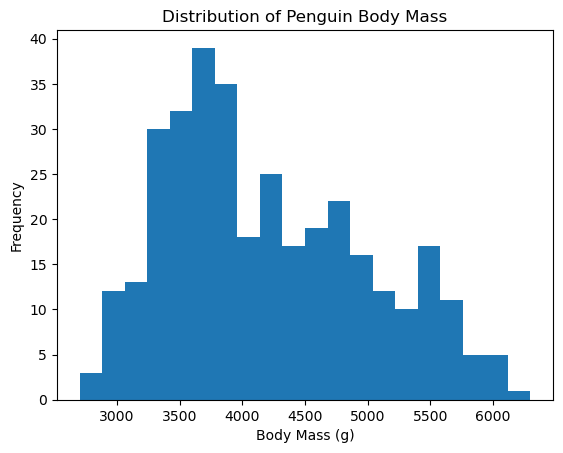

In [4]:
# Plotting a histrogram to view trends in body mass. https://realpython.com/python-histograms/
plt.hist(df["body_mass_g"].dropna(), bins=20)

plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")
plt.title("Distribution of Penguin Body Mass")

plt.show()


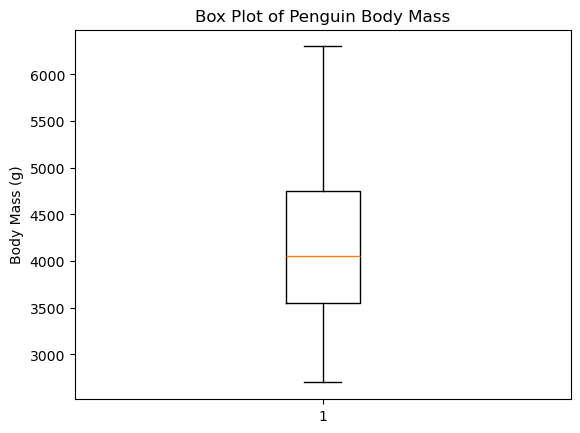

In [5]:
# Plotting a box plot to compare with above. https://www.geeksforgeeks.org/data-visualization/box-plot-in-python-using-matplotlib/
plt.boxplot(df["body_mass_g"].dropna())

plt.ylabel("Body Mass (g)")
plt.title("Box Plot of Penguin Body Mass")

plt.show()

The histogram shows the overall shape of the distribution of penguin body mass, including where values are most frequent and whether the data is skewed. Most observations are concentrated between the 3,500g and 4,500g range, but there is a wide range of body sizes in the dataset.

The box plot summarises the same data using the median and quartiles, showing the median mass as around 4,050g. The box plot reflects the presence of much lighter and heavier penguins with its spread, which is consistent with multiple species.

The histogram highlights the overall spread and shape of the data, but the box plot makes the central tendancy and range clearer.

## Problem 7: Investigating Relationships

Here I will look at the relationship between body mass and bill length using a scatter plot.

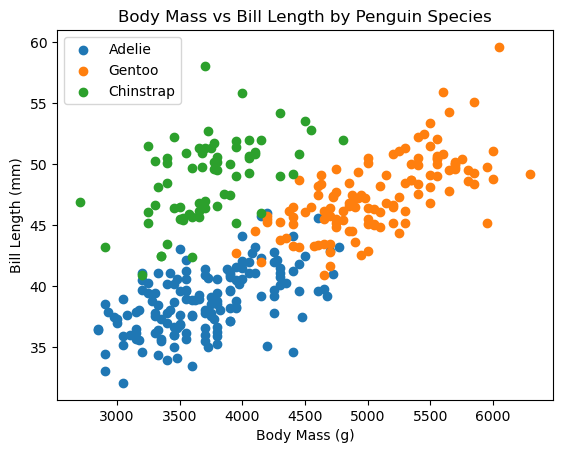

In [6]:
# Using pyplot to create a scatterplot of body mass vs bill length by penguin species. Used this video as a guide: https://www.youtube.com/watch?v=zZZ_RCwp49g

species = df["species"].unique()

for s in species:
    subset = df[df["species"] == s]
    plt.scatter(
        subset["body_mass_g"],
        subset["bill_length_mm"],
        label=s
    )

plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.title("Body Mass vs Bill Length by Penguin Species")
plt.legend()
plt.show()

The scatter plot suggests a positive relationship between body mass and bill length, with heavier penguins generally having longer bills.
The data also shows clear clustering by species, indicating that the relationship differs across Adelie, Chinstrap, and Gentoo penguins.
Gentoo penguins tend to have higher body mass and longer bill lengths compared to the other species.
Overall, while there is a visible trend, species appears to play an important role in the relationship between body mass and bill length.

## Problem 8: Modelling the Data

Adding a linear model & using R-squared to explain the proportion of variance i the dependent variable that can be attributed to the independent variable - in this case, how much the variance of bill length can be attributed to the independent variable, body mass.

In [7]:
# Taking my variables (body mass & bill length) for analysis, removing rows with missing values to ensure model is complete.
x = df["body_mass_g"]
y = df["bill_length_mm"]

mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

In [8]:
# Using Numpy's polyfit to predict a slope & "best-fit" straight line: https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/
coefficients = np.polyfit(x, y, 1)
slope, intercept = coefficients

line = slope * x + intercept

In [9]:
# Finding the R-Squared value (total data variation) - how far is the model's prediction from actual values: https://realpython.com/linear-regression-in-python/ 
y_pred = slope * x + intercept

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)
r_squared

np.float64(0.35415570314218703)

In [10]:
# Using SciPy to check how well the line fits: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html & https://www.geeksforgeeks.org/artificial-intelligence/regression-analysis-with-scipy/
scipy_result = linregress(x, y)

scipy_slope = scipy_result.slope
scipy_intercept = scipy_result.intercept
scipy_r_squared = scipy_result.rvalue ** 2

scipy_slope, scipy_intercept, scipy_r_squared

(np.float64(0.004051416583945234),
 np.float64(26.898872423598537),
 np.float64(0.35415570314218725))

I'm using SciPy's `linregress`function here to verify my slope and r-squared values from NumPy's valution. 

The results returned by `linregress`show the r-squared value as an almost exact match, confirming the results of my linear model.

In [ ]:
# Tidying my results with f-strings: https://www.datacamp.com/tutorial/python-f-string?utm_cid=23340058065&utm_aid=192632748929&utm_campaign=230119_1-ps-dscia~dsa-tofu~python_2-b2c_3-emea_4-prc_5-na_6-na_7-le_8-pdsh-go_9-nb-e_10-na_11-na&utm_loc=1007864-&utm_mtd=-c&utm_kw=&utm_source=google&utm_medium=paid_search&utm_content=ps-dscia~emea-en~dsa~tofu~tutorial~python&gad_source=1&gad_campaignid=23340058065&gclid=CjwKCAjw-8vPBhBbEiwAoA39Wtxa7ZPe3g--QHgWrpDqAVHTdQ5bcwyPxUfq3a8Vq3Ght40efW3BURoCypIQAvD_BwE
print(f"Slope (NumPy): {slope:.3f}")
print(f"Intercept (NumPy): {intercept:.3f}")
print(f"R-squared (NumPy): {r_squared:.3f}")

print(f"Slope (SciPy): {scipy_slope:.3f}")
print(f"Intercept (SciPy): {scipy_intercept:.3f}")
print(f"R-squared (SciPy): {scipy_r_squared:.3f}")

Slope (NumPy): 0.004
Intercept (NumPy): 26.899
R-squared (NumPy): 0.354
Slope (SciPy): 0.004
Intercept (SciPy): 26.899
R-squared (SciPy): 0.354


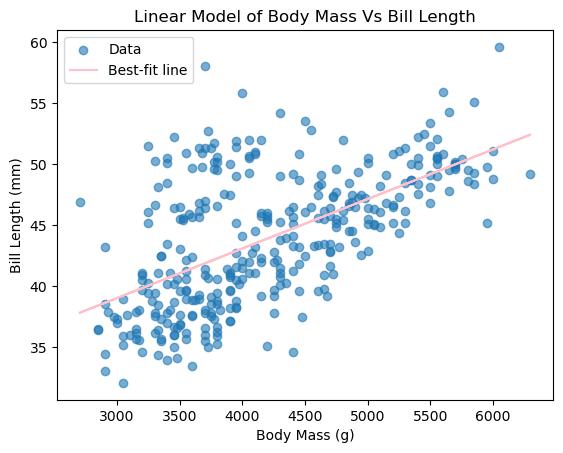

In [13]:
# Using scatter plot from Problem 7
plt.scatter(x, y, alpha=0.6, label="Data")

plt.plot(x, y_pred, color="pink", label="Best-fit line")

plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.title("Linear Model of Body Mass Vs Bill Length")
plt.legend()
plt.show()

The moderate R-squared value suggests that body mass is a useful predictor of bill length, but not a full predictor. The overall line does not fit very well due to the variance in species. If we add species as a predictor, or did 3 different regression charts for each species, we would expect it to fit better.

## End